# Time Series Simulation with Dynamic Heat Demand
This notebook sets up a district heating loop with two dynamic heat consumers and runs a 24-hour time series simulation using `pandapipes`.

## Imports and Logger Configuration

In [1]:
import pandapipes as pp
import pandapower as ppw
import pandas as pd
import numpy as np
import tempfile
import logging
import os
from pandapower.timeseries.output_writer import OutputWriter
import matplotlib.pyplot as plt

logger=logging.getLogger(__name__)
logger.setLevel(logging.WARNING)

## Create Network and Junctions
We define a circular topology with five junctions and connecting pipes.

In [2]:
net=pp.create_empty_network(fluid="water")

j0=pp.create_junction(net,pn_bar=1,tfluid_k=293.15,name="j0",geodata=(0, 0))
j1=pp.create_junction(net,pn_bar=1,tfluid_k=293.15,name="j1",geodata=(1, 0))
j2=pp.create_junction(net,pn_bar=1,tfluid_k=293.15,name="j2",geodata=(2, 0))
j3=pp.create_junction(net,pn_bar=1,tfluid_k=293.15,name="j3",geodata=(2, 1))
j4=pp.create_junction(net,pn_bar=1,tfluid_k=293.15,name="j4",geodata=(1, 1))

pp.create_pipe_from_parameters(net,from_junction=j0, to_junction=j1, length_km=1,diameter_m=0.1,name="Pipe 0-1")
pp.create_pipe_from_parameters(net,from_junction=j1, to_junction=j2, length_km=1,diameter_m=0.1,name="Pipe 1-2")
pp.create_pipe_from_parameters(net,from_junction=j2, to_junction=j3, length_km=1,diameter_m=0.1,name="Pipe 2-3")
pp.create_pipe_from_parameters(net,from_junction=j3, to_junction=j4, length_km=1,diameter_m=0.1,name="Pipe 3-4")
pp.create_pipe_from_parameters(net,from_junction=j4, to_junction=j0, length_km=1,diameter_m=0.1,name="Pipe 4-0")



np.int64(4)

## Add Pump and Heat Consumers
A circulation pump supplies hot water. Two consumers with high heat demands are added.

In [3]:

# Create circulation pump (80°C supply temperature)
pp.create_circ_pump_const_pressure(net, 
                                 return_junction=j0, 
                                 flow_junction=j1, 
                                 p_flow_bar=5, 
                                 plift_bar=0.7, 
                                 t_flow_k=273.15 + 80)

# Create heat consumers with higher heat demand
pp.create_heat_consumer(
    net,
    from_junction=j1,
    to_junction=j2,
    diameter_m=0.1,
    controlled_mdot_kg_per_s=0.5,
    qext_w=100000,  # 100 kW heat extraction
    name="Consumer 1"
)

pp.create_heat_consumer(
    net,
    from_junction=j3,
    to_junction=j4,
    diameter_m=0.1,
    controlled_mdot_kg_per_s=0.5,
    qext_w=80000,  # 80 kW heat extraction
    name="Consumer 2"
)

diameter_m is deprecated as it has no effect on the calculation and results. Nonetheless, it will be stored in the compoent table for postprocessing purposes by you if required.
diameter_m is deprecated as it has no effect on the calculation and results. Nonetheless, it will be stored in the compoent table for postprocessing purposes by you if required.


np.int64(1)

## Define Time Series and Load Profiles
Dynamic hourly profiles for the heat demand are defined using sine and cosine functions.

In [4]:
# Time series setup
time_steps = 24
time = pd.date_range('2024-01-01', periods=time_steps, freq='h')

# Create heat demand profiles with higher base loads and variations
consumer1_qext_profile = pd.Series(
    [100000 + 20000 * np.sin(2 * np.pi * t / time_steps) 
     for t in range(time_steps)], 
    index=time
)

consumer2_qext_profile = pd.Series(
    [80000 + 20000 * np.cos(2 * np.pi * t / time_steps) 
     for t in range(time_steps)], 
    index=time
)

class DFData:
  def __init__(self,data):
    self.data=data

  def get_time_step_value(self,time_step,profile_name=None,scale_factor=1.0):
    value=self.data.iloc[time_step]
    return value*scale_factor

profiles={
    # "heat_exchanger":DFData(heat_exchanger_profile),
    "consumer1":DFData(consumer1_qext_profile),
    "consumer2":DFData(consumer2_qext_profile)
}

sinkdata=profiles['consumer1']

print(sinkdata.data)


2024-01-01 00:00:00    100000.000000
2024-01-01 01:00:00    105176.380902
2024-01-01 02:00:00    110000.000000
2024-01-01 03:00:00    114142.135624
2024-01-01 04:00:00    117320.508076
2024-01-01 05:00:00    119318.516526
2024-01-01 06:00:00    120000.000000
2024-01-01 07:00:00    119318.516526
2024-01-01 08:00:00    117320.508076
2024-01-01 09:00:00    114142.135624
2024-01-01 10:00:00    110000.000000
2024-01-01 11:00:00    105176.380902
2024-01-01 12:00:00    100000.000000
2024-01-01 13:00:00     94823.619098
2024-01-01 14:00:00     90000.000000
2024-01-01 15:00:00     85857.864376
2024-01-01 16:00:00     82679.491924
2024-01-01 17:00:00     80681.483474
2024-01-01 18:00:00     80000.000000
2024-01-01 19:00:00     80681.483474
2024-01-01 20:00:00     82679.491924
2024-01-01 21:00:00     85857.864376
2024-01-01 22:00:00     90000.000000
2024-01-01 23:00:00     94823.619098
Freq: h, dtype: float64


## Setup Time Series Controls
Use `ConstControl` to apply the time-varying heat demand to the consumers.

In [5]:
from pandapower.control import ConstControl
from pandapipes.timeseries.run_time_series import run_timeseries

# heat_exchanger_control=ConstControl(net,element='heat_exchanger',variable='qext_w', element_index=[0],profile_name='heat_exchanger',data_source=profiles['heat_exchanger'])
consumer1_control = ConstControl(
    net,
    element='heat_consumer',
    variable='qext_w',
    element_index=[0],
    profile_name='consumer1',
    data_source=profiles['consumer1']
)

consumer2_control = ConstControl(
    net,
    element='heat_consumer',
    variable='qext_w',
    element_index=[1],
    profile_name='consumer2',
    data_source=profiles['consumer2']
)

## Initialize Output Writer
The default output writer logs relevant flow and temperature variables.

In [6]:
# Custom init_default_outputwriter function
def custom_init_default_outputwriter(net, time_steps, **kwargs):
    output_writer = kwargs.get("output_writer", None)
    if output_writer is not None:
        net.output_writer.iat[0, 0] = output_writer
    if "output_writer" not in net or net.output_writer.iat[0, 0] is None:
        ow = OutputWriter(net, time_steps, output_path=tempfile.gettempdir(), log_variables=[])

        # Define a mapping of network components to result variables
        component_to_variables = {
            'sink': [('res_sink', 'mdot_kg_per_s')],
            'source': [('res_source', 'mdot_kg_per_s')],
            'ext_grid': [('res_ext_grid', 'mdot_kg_per_s')],
            'pipe': [('res_pipe', 'v_mean_m_per_s'),
                     ('res_pipe', 't_from_k'),  # Pipe temperature at the start
                     ('res_pipe', 't_to_k')],   # Pipe temperature at the end
            'junction': [('res_junction', 'p_bar'),
                         ('res_junction', 't_k')]
        }

        # Iterate through the mapping and log variables for existing components
        for component, variables in component_to_variables.items():
            if hasattr(net, component):  # Check if the component exists in the network
                for var, value in variables:
                    ow.log_variable(var, value)

        logger.info("No output writer specified. Using default:")
        logger.info(ow)
        logger.info("Using custom output writer configuration.")
    return net.output_writer.iat[0, 0]


from pandapipes.timeseries import init_default_outputwriter



## Run Time Series Simulation

In [7]:
output_path = "simulation_results.csv"

# Initialize the default output writer (from pandapipes)
ow = init_default_outputwriter(net, time_steps, output_path=output_path)

# Run the time series simulation
print("\nRunning time series simulation...")
try:
    pp.timeseries.run_timeseries(net, 
                                time_steps=list(range(time_steps)), 
                                mode="sequential",
                                continue_on_divergence=True)
    print("Simulation completed successfully!")
except Exception as e:
    print(f"Simulation error: {str(e)}")
    print("\nAttempting single timestep simulation...")
    pp.pipeflow(net, mode="sequential")



Running time series simulation...


  0%|          | 0/24 [00:00<?, ?it/s]

100%|██████████| 24/24 [00:00<00:00, 47.87it/s]

Simulation completed successfully!


## Extract and Save Simulation Results

In [8]:
# Output the results
print("Time Series Simulation Results:")
print(net.res_junction)
print(net.res_pipe)

output_data = {}

# Collecting the logged data from the output_writer
for key, value in net.output_writer.iat[0, 0].output.items():
    output_data[key] = value

output_path = "simulation_results_manual.xlsx"

# Save each logged variable to a separate sheet in the Excel file
with pd.ExcelWriter(output_path) as writer:
    for key, df in output_data.items():
        df.to_excel(writer, sheet_name=key)

# Check if the file was created
if os.path.exists(output_path):
    print(f"Logs successfully saved to: {output_path}")
else:
    print(f"Failed to save logs to: {output_path}")

# Print available keys for debugging
print("\nAvailable data keys:")
for key in output_data.keys():
    print(f"- {key}")


Time Series Simulation Results:
      p_bar         t_k
0  4.300000  348.237309
1  5.000000  353.150000
2  4.856096  346.201096
3  4.651519  346.201096
4  4.504577  338.938952
   v_mean_m_per_s  p_from_bar  p_to_bar    t_from_k      t_to_k  t_outlet_k  \
0       -0.781307    4.300000  5.000000  348.237309  353.150000  353.150000   
1        0.350568    5.000000  4.856096  353.150000  346.201096  353.150000   
2        0.414294    4.856096  4.651519  346.201096  346.201096  346.201096   
3        0.349060    4.651519  4.504577  346.201096  338.938952  346.201096   
4        0.412547    4.504577  4.300000  338.938952  348.237309  338.938952   

   mdot_from_kg_per_s  mdot_to_kg_per_s  vdot_m3_per_s      reynolds    lambda  
0           -5.962676          5.962676      -0.006136  76022.633934  0.024246  
1            2.675423         -2.675423       0.002753  62422.434630  0.024429  
2            3.175423         -3.175423       0.003254  40485.805221  0.024985  
3            2.675423    

## Plot Temperature Distribution
Visualize the junction and pipe temperatures over the day.

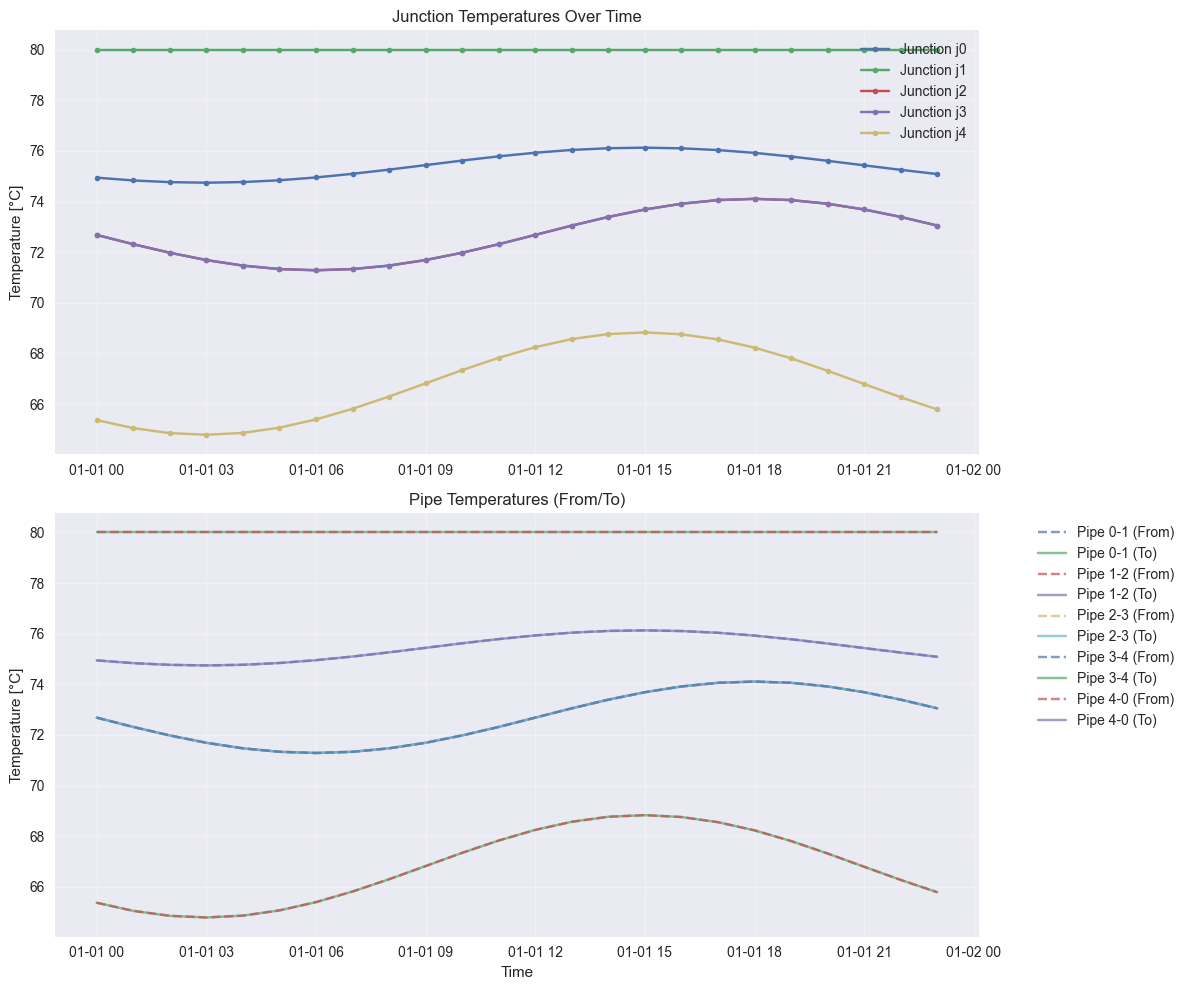

In [9]:
# Create output directory for plots
output_dir = "simulation_plots"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Create visualizations
plt.style.use('seaborn-v0_8')

# 1. Temperature Distribution Plot
plt.figure(figsize=(12, 10))

# Plot junction temperatures
plt.subplot(2, 1, 1)
temps = output_data['res_junction.t_k'] - 273.15  # Convert to Celsius
for i, name in enumerate(['j0', 'j1', 'j2', 'j3', 'j4']):
    plt.plot(time, temps.iloc[:, i], '-o', label=f'Junction {name}', markersize=4)

plt.title('Junction Temperatures Over Time', fontsize=12)
plt.ylabel('Temperature [°C]')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot pipe temperatures
plt.subplot(2, 1, 2)
pipe_temps_from = output_data['res_pipe.t_from_k'] - 273.15
pipe_temps_to = output_data['res_pipe.t_to_k'] - 273.15

for i, name in enumerate(['Pipe 0-1', 'Pipe 1-2', 'Pipe 2-3', 'Pipe 3-4', 'Pipe 4-0']):
    plt.plot(time, pipe_temps_from.iloc[:, i], '--', label=f'{name} (From)', alpha=0.7)
    plt.plot(time, pipe_temps_to.iloc[:, i], '-', label=f'{name} (To)', alpha=0.7)

plt.title('Pipe Temperatures (From/To)', fontsize=12)
plt.xlabel('Time')
plt.ylabel('Temperature [°C]')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'temperature_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

## Plot Flow Velocities
Flow velocities in each pipe across the simulation time.

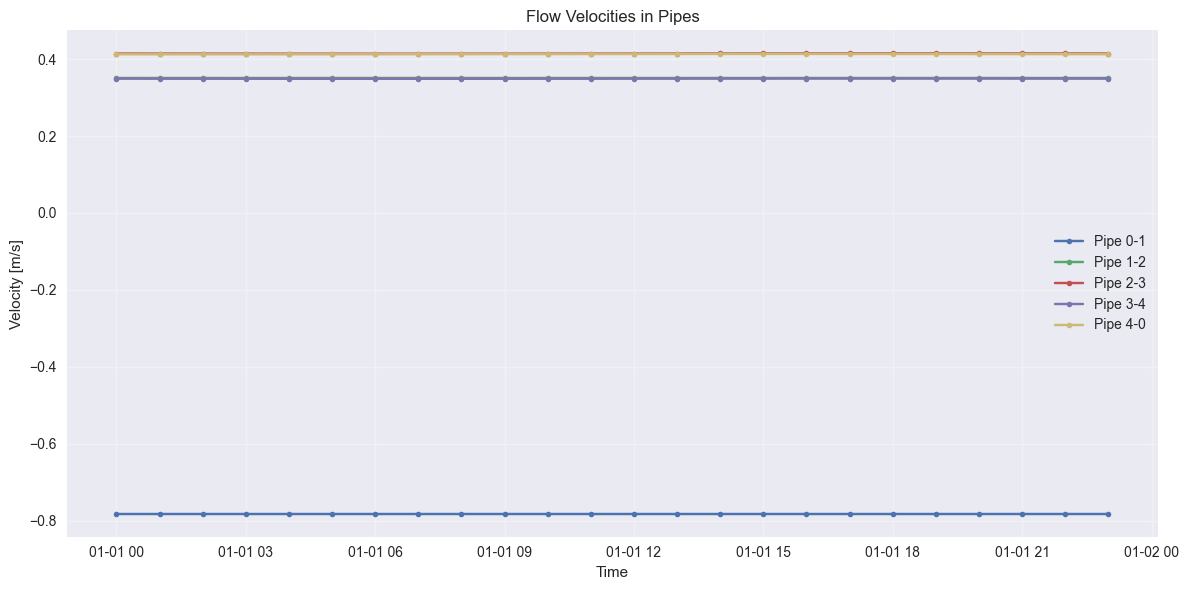

In [10]:
# 2. Flow Velocities Plot
plt.figure(figsize=(12, 6))
velocities = output_data['res_pipe.v_mean_m_per_s']
for i, name in enumerate(['Pipe 0-1', 'Pipe 1-2', 'Pipe 2-3', 'Pipe 3-4', 'Pipe 4-0']):
    plt.plot(time, velocities.iloc[:, i], '-o', label=name, markersize=4)

plt.title('Flow Velocities in Pipes', fontsize=12)
plt.xlabel('Time')
plt.ylabel('Velocity [m/s]')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'flow_velocities.png'), dpi=300, bbox_inches='tight')
plt.show()

## Summary Statistics

In [11]:
# Print summary statistics
print("\nSimulation Summary:")
print(f"Average Junction Temperatures:")
for i, name in enumerate(['j0', 'j1', 'j2', 'j3', 'j4']):
    print(f"{name}: {temps.iloc[:, i].mean():.1f}°C")

print(f"\nAverage Flow Velocities:")
for i, name in enumerate(['Pipe 0-1', 'Pipe 1-2', 'Pipe 2-3', 'Pipe 3-4', 'Pipe 4-0']):
    print(f"{name}: {velocities.iloc[:, i].mean():.2f} m/s")


Simulation Summary:
Average Junction Temperatures:
j0: 75.4°C
j1: 80.0°C
j2: 72.7°C
j3: 72.7°C
j4: 66.8°C

Average Flow Velocities:
Pipe 0-1: -0.78 m/s
Pipe 1-2: 0.35 m/s
Pipe 2-3: 0.41 m/s
Pipe 3-4: 0.35 m/s
Pipe 4-0: 0.41 m/s


## Network Visualization at Selected Time Steps
Color-coded junctions show temperature distribution at 5 selected hours.

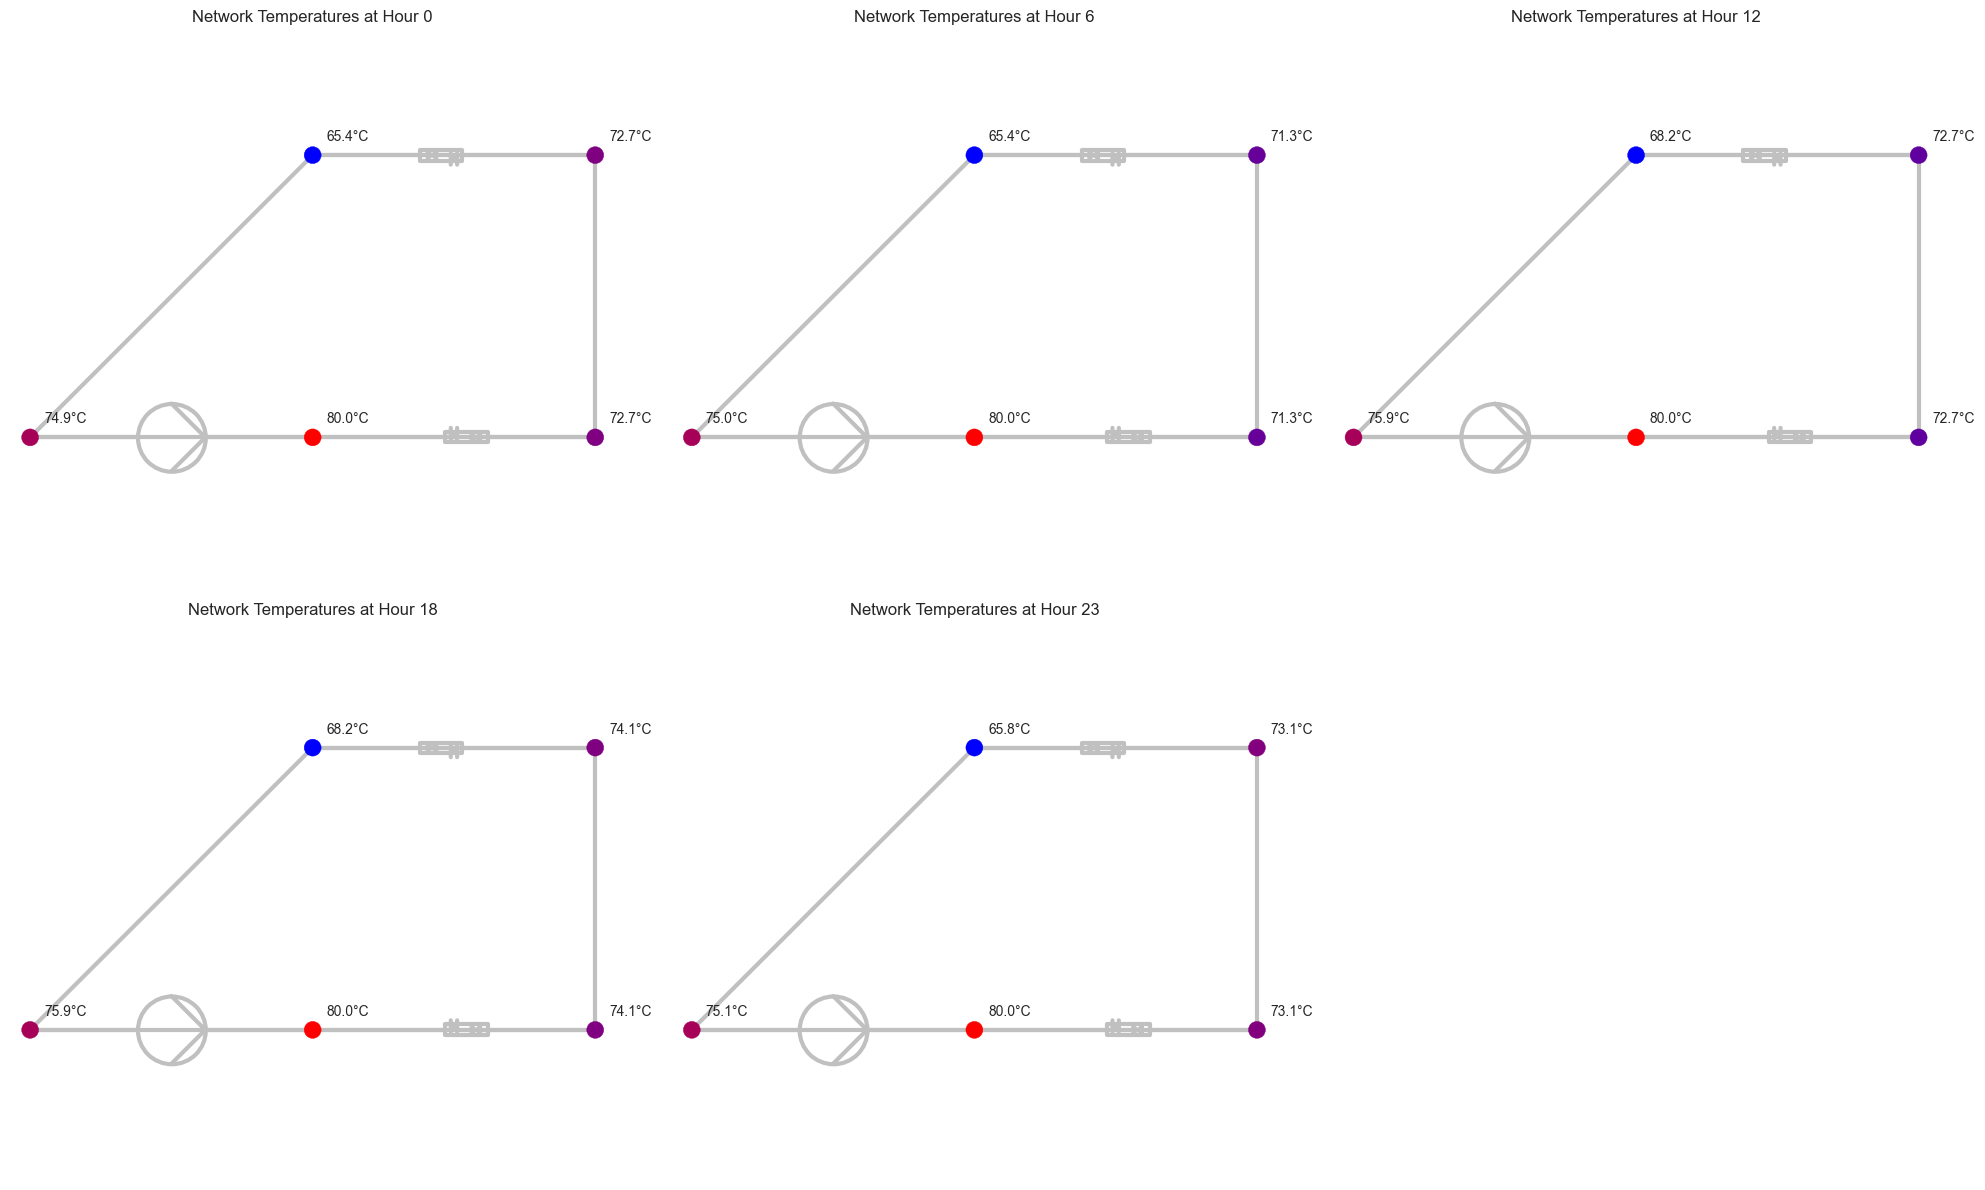

In [13]:
# Add network visualization code after the simulation
def plot_network_timestep(net, timestep, temperatures, ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Create a color map based on temperatures
    temp_min = temperatures.min()
    temp_max = temperatures.max()
    
    # Map temperatures to colors (red=hot, blue=cold)
    junction_colors = []
    for temp in temperatures:
        # Convert to RGB color (red=hot, blue=cold)
        normalized_temp = (temp - temp_min) / (temp_max - temp_min)
        junction_colors.append((normalized_temp, 0, 1-normalized_temp))
    
    # Plot the network
    pp.plotting.simple_plot(
        net,
        plot_sinks=True,
        sink_size=1.0,
        junction_size=2.0,
        pipe_width=3.0,
        junction_color=junction_colors,
        ax=ax,
        show_plot=False
    )
    
    # Add temperature labels to junctions
    for i, (x, y) in enumerate(zip(net.junction_geodata.x, net.junction_geodata.y)):
        ax.annotate(f'{temperatures[i]:.1f}°C', 
                   (x, y), 
                   xytext=(10, 10),
                   textcoords='offset points')
    
    ax.set_title(f'Network Temperatures at Hour {timestep}')
    return ax
# Create subplots for 5 timesteps
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# Select 5 timesteps evenly spaced
selected_timesteps = [0, 6, 12, 18, 23]  # Beginning, 6h, 12h, 18h, and end of day

# Get temperature data for all junctions
junction_temps = output_data['res_junction.t_k'] - 273.15  # Convert to Celsius

# Plot each timestep
for i, timestep in enumerate(selected_timesteps):
    plot_network_timestep(net, timestep, junction_temps.iloc[timestep], ax=axes[i])

# Remove the extra subplot
axes[-1].remove()

plt.tight_layout()
plt.savefig('network_temperatures.png', dpi=300, bbox_inches='tight')
plt.show()